In [1]:
import os

os.chdir("..")

Exploring Data
==============

Now that you have a solid foundation in the basic functions and data structures
of Python, you can move on to using it for data analysis. In this chapter,
you'll learn how to efficiently explore and summarize with visualizations and
statistics. Along the way, you'll also learn how to write and apply functions
along entire sets of data in Pandas DataFrames and Series.

:::{admonition} Learning Objectives
* Describe how Python iterates over data
* Perform various iterations, including for-loops and list comprehension
* Use Pandas aggregation methods to explore a data set
* Prepare data for visualization
* Describe the grammar of graphics
* Use the grammar of graphics to produce a plot
* Identify where to go to learn more about making effective visualizations
:::


Setup
-----

### Packages

As in the last chapter, you will be working with two primary packages: NumPy
and Pandas. Later, you will load another set of packages to visualize your
data.

In [2]:
import numpy as np
import pandas as pd

### Data

We will continue working with the banknotes data set. Once you've imported your
packages, load this data in as well.

In [3]:
banknotes = pd.read_csv("data/banknotes.csv")

You're now ready to go.


(iteration)=
Iterating Over Data
-------------------

Before we go into data exploration in full, it's important to understand how
Python/Pandas computes summary statistics about a data set.
{numref}`summarizing-columns` introduced column-wise operations in Pandas; you
will learn more of them below. These operations are a convenient and efficient
way to compute multiple results at once, and with only a few lines of code.

Under the hood, Pandas has to **iterate** over each value in a cell to perform
operations like `.mean` or `.min`. We can do this too using a **for-loop**.


### For-Loops

For-loops iterate over some object and compute something for each element. Each
one of these computations is one **iteration**. A for-loop begins with the
`for` keyword, followed by:

* A placeholder variable, which will be automatically signed to an element at
  the beginning of each iteration
* The `in` keyword
* An object with elements
* A colon `:`

Code in the body of the loop must be indented by 4 spaces.

For example, to print out all the column names in `banknotes.columns`, you can
write:

In [4]:
for column in banknotes.columns:
    print(column)

currency_code
country
currency_name
name
gender
bill_count
profession
known_for_being_first
current_bill_value
prop_total_bills
first_appearance_year
death_year
comments
hover_text
has_portrait
id
scaled_bill_value


Within the indented part of a for-loop, you can compute values, check
conditions, etc.

In [5]:
for value in banknotes["bill_count"]:
    if value < 1:
        print(value)

0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.33
0.33
0.33
0.33
0.33
0.33
0.33
0.33
0.33
0.33
0.33
0.33
0.33
0.33
0.33
0.25
0.25
0.25
0.25
0.33
0.33
0.33
0.5
0.5
0.33
0.5
0.33
0.33
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.33
0.33
0.33
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.33
0.33
0.33
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5


Oftentimes you want to save the result of the code you perform within a
for-loop. The easiest way to do this is by creating an empty list and using
`append` to add values to it.

In [6]:
result = []
for value in banknotes["current_bill_value"]:
    if value % 25 == 0:
        result.append(value)

result

[100,
 100,
 50,
 50,
 50,
 100,
 100,
 1000,
 500,
 200,
 100,
 50,
 50,
 50,
 100,
 200,
 100,
 50,
 200,
 200,
 100,
 50,
 100,
 5000,
 1000,
 10000,
 20000,
 2000,
 50000,
 20000,
 2000,
 10000,
 100000,
 1000,
 20000,
 5000,
 50000,
 2000,
 10000,
 10000,
 5000,
 20000,
 50000,
 2000,
 1000,
 2000,
 5000,
 1000,
 200,
 500,
 5000,
 2000,
 1000,
 500,
 200,
 100,
 200,
 200,
 200,
 500,
 2000,
 100,
 2000,
 100,
 100,
 500,
 50,
 50,
 200,
 50,
 100,
 500,
 100000,
 5000,
 100000,
 10000,
 50000,
 20000,
 50000,
 20000,
 2000,
 1000,
 2000,
 10000,
 200,
 100,
 50,
 2000,
 500,
 10000,
 5000,
 1000,
 500,
 1000,
 100,
 50,
 500,
 1000,
 10000,
 5000,
 5000,
 500,
 200,
 100,
 50,
 1000,
 5000,
 1000,
 50000,
 10000,
 1000,
 200,
 50,
 500,
 2000,
 100,
 500,
 500,
 1000,
 1000,
 1000,
 500,
 200,
 200,
 100,
 100,
 500,
 1000,
 100,
 200,
 1000,
 50,
 100,
 100,
 50,
 100,
 200,
 50,
 500,
 100,
 500,
 200,
 50,
 1000,
 1000,
 1000,
 50,
 100,
 5000,
 2000,
 100,
 1000,
 500,
 200,

### List Comprehensions

A more succinct way to perform certain `append` operations is with a **list
comprehension**. A list comprehension is very similar to a for-loop, but it
automatically creates a new list based on what your iterations do. This means
you do not need to create an empty list ahead of time.

Below, this comprehension divides each value in the `current_bill_value` column
by 2.

In [7]:
[value / 2 for value in banknotes["current_bill_value"]]

[50.0,
 50.0,
 25.0,
 10.0,
 5.0,
 25.0,
 5.0,
 10.0,
 5.0,
 25.0,
 50.0,
 50.0,
 10.0,
 2.5,
 10.0,
 500.0,
 250.0,
 100.0,
 50.0,
 25.0,
 5.0,
 2.5,
 1.0,
 25.0,
 25.0,
 5.0,
 50.0,
 100.0,
 50.0,
 25.0,
 5.0,
 5.0,
 10.0,
 100.0,
 10.0,
 100.0,
 50.0,
 10.0,
 2.5,
 25.0,
 50.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 10.0,
 2500.0,
 500.0,
 5000.0,
 10000.0,
 1000.0,
 25000.0,
 10000.0,
 1000.0,
 5000.0,
 50000.0,
 500.0,
 10000.0,
 2500.0,
 25000.0,
 1000.0,
 5000.0,
 5000.0,
 2500.0,
 10000.0,
 25000.0,
 1000.0,
 500.0,
 1000.0,
 2500.0,
 500.0,
 100.0,
 250.0,
 2500.0,
 1000.0,
 500.0,
 250.0,
 100.0,
 50.0,
 100.0,
 100.0,
 100.0,
 250.0,
 1000.0,
 50.0,
 1000.0,
 50.0,
 50.0,
 10.0,
 250.0,
 2.5,
 25.0,
 10.0,
 5.0,
 2.5,
 5.0,
 10.0,
 25.0,
 2.5,
 1.0,
 100.0,
 0.5,
 5.0,
 10.0,
 25.0,
 50.0,
 250.0,
 50000.0,
 2500.0,
 50000.0,
 5000.0,
 25000.0,
 10000.0,
 25000.0,
 10000.0,
 1000.0,
 500.0,
 1000.0,
 5000.0,
 100.0,
 50.0,
 25.0,
 10.0,
 1000.0,
 250.0,
 5000.0,
 2500.0,
 500.0,
 25

Folding comparisons into list comprehensions works similar to subsetting in
Pandas:

In [8]:
[year for year in banknotes["first_appearance_year"] if year > 2012]

[2018,
 2018,
 2018,
 2018,
 2018,
 2018,
 2018,
 2018,
 2019,
 2018,
 2019,
 2018,
 2018,
 2017,
 2018,
 2017,
 2017,
 2015,
 2015,
 2015,
 2015,
 2014,
 2014,
 2014,
 2014,
 2014,
 2014,
 2016,
 2021,
 2020,
 2017,
 2016,
 2016,
 2016,
 2016,
 2016,
 2016,
 2015,
 2017,
 2014,
 2017,
 2013,
 2020,
 2020,
 2021,
 2021,
 2015,
 2016,
 2015,
 2015,
 2015,
 2015,
 2013,
 2020,
 2017,
 2013,
 2013,
 2019,
 2015,
 2018,
 2018,
 2018,
 2018]

You can assign the results to a new variable and perform further computations
on them:

In [9]:
recent_years = [year for year in banknotes["first_appearance_year"] if year > 2012]
np.median(recent_years)

2017.0

(aggregate-functions)=
Aggregate Functions
-------------------


(aggregating-a-column)=
### Aggregating a Column

In {numref}`summarizing-columns`, you learned how to compute the mean, minimum,
and maximum values from a Series. Pandas offers a more generalized way to
handle these functions through its `.aggregate` method. This method
**aggregates** the elements of Series, reducing the Series to a smaller number
of values (usually one value).

For example, to compute the median of all values in `first_appearance_year`:

In [10]:
banknotes["first_appearance_year"].aggregate('median')

1996.0

The `.agg` method is an alias for `.aggregate`. The [Pandas
documentation][pandasdocs] advises that you use the alias:

[pandasdocs]: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.aggregate.html

In [11]:
banknotes["first_appearance_year"].agg('median')

1996.0

You can pass functions to `.agg` in addition to names of functions:

In [12]:
banknotes["first_appearance_year"].agg(np.median)

1996.0

The method is particularly powerful for its ability to handle multiple
functions at once, using a list. Below, we compute the mean, median, and
standard deviation for `bill_count`:

In [13]:
banknotes["current_bill_value"].agg([np.mean, np.median, np.std])

mean       4038.956989
median      100.000000
std       14336.386917
Name: current_bill_value, dtype: float64

Aggregation methods can also work on multiple columns at once:

In [14]:
banknotes[["current_bill_value", "scaled_bill_value"]].agg(np.mean)

current_bill_value    4038.956989
scaled_bill_value        0.306058
dtype: float64

(aggregating-within-groups)=
### Aggregating within Groups

Aggregation is especially useful when combined with grouping. The `.groupby`
method groups rows of a DataFrame using the columns you specify. The grouping
columns should generally be categories rather than decimal numbers. For
example, to group the banknotes by `gender` and then count how many entries are
in each group:

In [15]:
banknotes.groupby("gender").size()

gender
F     59
M    220
dtype: int64

Use bracket notation to look at a specific column for each group:

In [16]:
banknotes.groupby("gender")["current_bill_value"].mean()

gender
F    2062.745763
M    4568.940909
Name: current_bill_value, dtype: float64

It's also possible to group by multiple conditions:

In [17]:
banknotes.groupby(["gender", "profession"]).size()

gender  profession      
F       Activist             4
        Head of Gov't        1
        Monarch              8
        Musician             5
        Other                3
        Performer            1
        Politician           4
        Religious figure     2
        Revolutionary        9
        STEM                 2
        Visual Artist        6
        Writer              14
M       Educator             4
        Founder             45
        Head of Gov't       42
        Military            13
        Monarch             10
        Musician             7
        Other                2
        Performer            2
        Politician          23
        Religious figure     1
        Revolutionary       19
        STEM                14
        Visual Artist        7
        Writer              31
dtype: int64

By default, the grouping columns are moved to the index of the result. You can
prevent this by setting `as_index = False` in `.groupby`:

In [18]:
banknotes.groupby(["gender", "profession"], as_index = False).size()

,gender,profession,size
0,F,Activist,4
1,F,Head of Gov't,1
2,F,Monarch,8
3,F,Musician,5
4,F,Other,3
5,F,Performer,1
6,F,Politician,4
7,F,Religious figure,2
8,F,Revolutionary,9
9,F,STEM,2


:::{tip}
You can also "reset the index on a DataFrame, so that the current indexes
become columns with the `.reset_index` method.
:::

Leaving the grouping columns in the index is often convenient because you can
easily access results for the groups you're interested in:

In [19]:
grouped = banknotes.groupby(["gender", "profession"]).size()

grouped.loc[:, "Visual Artist"]

gender
F    6
M    7
dtype: int64

A few aggregation functions only make sense when used together with groups. One
is the `.first` method, which returns the first element or row. The `.first`
method is especially useful if all the values in a group are the same and you
want to reduce the data to one row per group. For instance, the same country
appears across multiple rows in our data set. With `.first`, you can select the
corresponding currency code:

In [20]:
banknotes.groupby(["country"])["currency_code"].first()

country
Argentina                 ARS
Australia                 AUD
Bangladesh                BDT
Bolivia                   BOB
Canada                    CAD
Cape Verde                CVE
Chile                     CLP
China                     RMB
Colombia                  COP
Costa Rica                CRC
Czech Republic            CZK
Dominican Republic        DOP
England                   GBP
Georgia                   GEL
Iceland                   ISK
Indonesia                 IDR
Israel                    ILS
Jamaica                   JMD
Japan                     JPY
Kyrgyzstan                KGS
Malawi                    MWK
Mexico                    MXN
New Zealand               NZD
Nigeria                   NGN
Papua New Guinea          PGK
Peru                      PEN
Philippines               PHP
Serbia                    RSD
South Africa              ZAR
South Korea               KRW
Sweden                    SEK
São Tomé and Príncipe     STD
Tunisia                   TND
Tu

(data-visualization-in-python)=
Data Visualization in Python
----------------------------


```{image} ../img/visualization_landscape.png
:alt: A network of Python visualization packages.
```

_Image from [Jake VanderPlas][jake]. See [here][viz] for a version with links
to all of the packages!_

[jake]: http://vanderplas.com/
[viz]: https://rougier.github.io/python-visualization-landscape/landscape-colors.html

Creating aggregated information about a data set is often done with the intent
to share your results. A data visualization is an effective medium for
displaying results, and there are many ways to create one in Python. In fact,
so many visualization packages are available that there is even [a
website][pyviz] dedicated to helping people decide which to use. This reader
focuses on **static visualization**, where the visualization is a still image.
Some popular packages for creating static visualizations are:

[pyviz]: https://pyviz.org/

* **[matplotlib][]** is the foundation for most other visualization packages.
  matplotlib is low-level, meaning it's flexible but even simple plots may take
  [5 lines of code or more][ex]. It's good to know a little bit about
  matplotlib, but it probably shouldn't be your primary visualization package.
  Familiarity with MATLAB makes it easier to learn matplotlib.

* **[pandas][]** provides built-in plotting functions, which can be convenient
  but are more limited than what you'll find in dedicated visualization
  packages. They're also inconsistent about the expected format of the data.

* **[plotnine][]** is a copy of the popular R package [ggplot2][]. The package
  uses the **grammar of graphics**, a convenient way to describe visualizations
  in terms of layers. Familiarity with R's [ggplot2][] or Julia's
  [Gadfly.jl][gadfly] package makes it easier to learn plotnine (and
  vice-versa).

* **[seaborn][]** is designed specifically for making statistical plots. It's
  well-documented and stable.

[matplotlib]: https://matplotlib.org/
[ex]: https://dsaber.com/2016/10/02/a-dramatic-tour-through-pythons-data-visualization-landscape-including-ggplot-and-altair/
[pandas]: https://pandas.pydata.org/docs/user_guide/visualization.html
[ggplot2]: https://ggplot2.tidyverse.org/
[plotnine]: https://plotnine.readthedocs.io/en/stable/
[gadfly]: http://gadflyjl.org/stable/
[seaborn]: https://seaborn.pydata.org/

There are also many packages available for making **interactive
visualizations**.

This reader focuses on plotnine, so that the visualization skills you learn
here will also be relevant if you end up using R or Julia. plotnine has
detailed [documentation][plotnine]. It's also useful to look at the [ggplot2
documentation][ggplot2] and [cheatsheet][ggplot2-cheat].

[ggplot2-cheat]: https://github.com/rstudio/cheatsheets/blob/master/data-visualization-2.1.pdf


(preparing-to-visualize)=
Preparing to Visualize
----------------------

Before building a visualization, you will need to do a few preparatory steps.

(install-import-plotnine)=
### Install and Import plotnine

While Matplotlib is included with Anaconda, plotnine is not. You will need to
install the plotnine package in order to use it. {numref}`installing-packages`
showed you how to install packages with conda via the Terminal:

```
conda install -c conda-forge plotnine
```

In {numref}`modules`, you learned how to import a module in a Python package
with the `import` keyword. Python also provides a `from` keyword to import
specific objects within a module. The syntax is:

```python
from <module> import <object>
```

When you import an object this way, you can access the object without the
module name as a prefix. For instance, if you imported Pandas using:

```python
from pandas import DataFrame
```

You could then write:

```python
df = DataFrame()
```

You can also use the from keyword to import all objects in a module with the
wildcard character `*`. Generally you shouldn't do this, because objects in a
module will overwrite objects in your code if they have the same name. However,
the plotnine package is designed to be imported this way:

In [21]:
from plotnine import *

(configure-jupyter)=
### Configure Jupyter

Jupyter notebooks can display most static visualizations and some interactive
visualizations. If you're going to use visualization packages that depend on
Matplotlib (such as plotnine), it's a good idea to set up your notebook by
running:

In [22]:
# Initialize matplotlib

%matplotlib inline

import matplotlib.pyplot as plt

# We'll see what this code does later on:
plt.rcParams["figure.figsize"] = [10, 8]

The last line sets the default size of plots. You can increase the numbers to
make plots larger, or decrease them to make plots smaller.


(data-cleaning)=
### Data Cleaning

Finally, we need to do a small amount of data cleaning. The plots below will
focus on two variables, `death_year` and `scaled_bill_value`. But some rows
lack information for these variables, so they need to be removed. Along the
way, we will ensure that the variables' datatypes are set correctly.

:::{tip}
When making potentially destructive changes to a data set, it's a good idea to
reassign the altered data to a new variable.
:::

**Death year**

In [23]:
no_death = banknotes["death_year"].isin([np.nan, "-"])
to_plot = banknotes[no_death == False].copy()
to_plot["death_year"] = to_plot["death_year"].astype(int)

**Scaled bill value**

In [24]:
no_scaled = to_plot["scaled_bill_value"].isna()
to_plot = to_plot[no_scaled == False]

you are now ready to make a plot.


(grammar-of-graphics)=
The Grammar of Graphics
-----------------------

Recall that plotnine is a clone of ggplot2. The "gg" in ggplot2 stands for
*grammar of graphics*. The idea of a grammar of graphics is that visualizations
can be built up in layers. Visualizations that adhere to this grammar must
have:

* Data
* Geometry
* Aesthetics

There are also several optional layers. Here are a few:

| Layer       | Description                                        |
| :---------- | :------------------------------------------------- |
| scales      | Title, label, and axis value settings              |
| facets      | Side-by-side plots                                 |
| guides      | Axis and legend position settings                  |
| annotations | Shapes that are not mapped to data                 |
| coordinates | Coordinate systems (Cartesian, logarithmic, polar) |

With all this in mind, it's time to make a plot. But what kind of plot should
we make? It depends on what we want to know about the data set. Suppose we want
to understand the relationship between a banknote's value and how long ago the
person on the banknote died, as well as whether this is affected by gender. One
way to show this is to make a scatter plot.


### Layer 1: Data

The data layer determines the data set used to make the plot. plotnine is
designed to work with *tidy* data. Tidy means:
1. Each observation has its own row
2. Each feature has its own column
3. Each value has its own cell

Tidy data sets are convenient in general. A later lesson will cover how to make
an untidy data set tidy. Until then, we'll take it for granted that the data
sets we work with are tidy.

To set up the data layer, call the ``ggplot` function on a Data Frame:

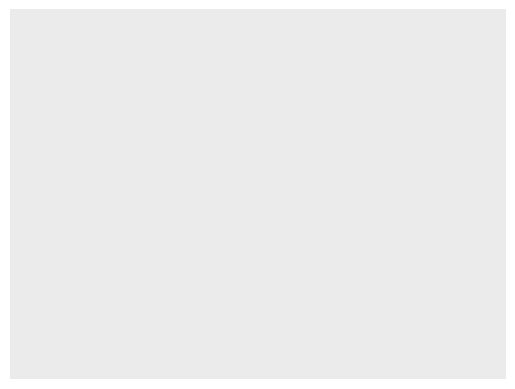

<ggplot: (327228693)>

In [25]:
ggplot(to_plot)

This returns a blank plot. We still need to add a few more layers.


### Layer 2: Geometry

The geometry layer determines the shape or appearance of the visual elements of
the plot. In other words, the geometry layer determines what kind of plot to
make: one with points, lines, boxes, or something else.

There are many different geometries available in plotnine. The package provides
a function for each geometry, always prefixed with `geom_`.

To add a geometry layer to the plot, choose the `geom_` function you want and
add it to the plot with the `+` operator:

In [26]:
ggplot(to_plot) + geom_point()

PlotnineError: 'geom_point requires the following missing aesthetics: x, y'

This returns an error message that we're missing aesthetics `x` and `y`. We'll
learn more about aesthetics in the next section, but this error message is
especially helpful: it tells us exactly what we're missing. When you use a
geometry you're unfamiliar with, it can be helpful to run the code for just the
data and geometry layer like this, to see exactly which aesthetics need to be
set.

As we'll see later, it's possible to add multiple geometries to a plot.


### Layer 3: Aesthetics

The aesthetic layer determines the relationship between the data and the
geometry. Use the aesthetic layer to map features in the data to aesthetics
(visual elements) of the geometry.

The `aes` function creates an aesthetic layer. The syntax is:

```python
aes(AESTHETIC = FEATURE, ...)
```

The names of the aesthetics depend on the geometry, but some common ones are
`x`, `y`, `color`, `fill`, `shape`, and `size`. There is more information about
and examples of aesthetic names in the documentation.

For example, we want to put `death_year` on the x-axis and `scalled_bill_value`
on the y-axis. It's best to use `scaled_bill_value` here rather than
`current_bill_value` because different countries use different scales of
curency. One United States Dollar is worth approximately one hundred Japanese
Yen, for example. Below, we will set the aesthetics for both of these values.
Notice however that the aesthetic layer is not added to the plot with the `+`
operator. Instead, it is passed as the second argument to the `ggplot`
function:

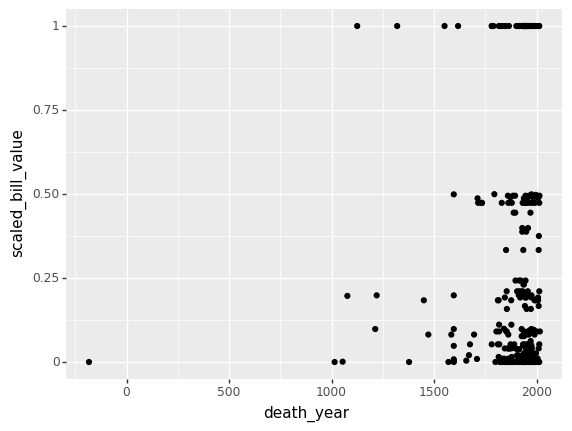

<ggplot: (328269221)>

In [27]:
ggplot(
    to_plot,
    aes(x = "death_year", y = "scaled_bill_value")
) + geom_point()

**Per-geometry Aesthetics**

When you add the aesthetic layer or pass it to the `ggplot` function, it
applies to the entire plot. You can also set an aesthetic layer individually
for each geometry by passing the layer as the first argument in the `geom_`
function:

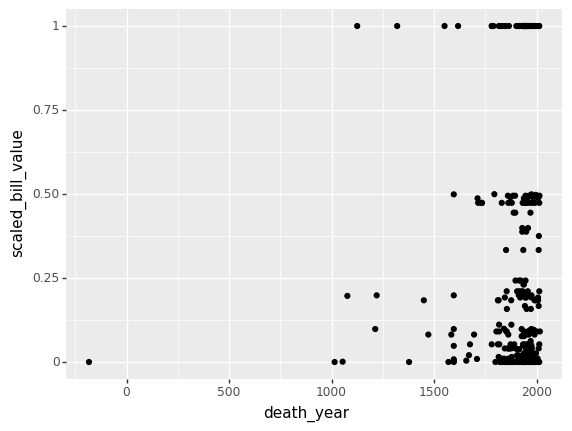

<ggplot: (328299247)>

In [28]:
(ggplot(to_plot) +
    geom_point(aes(x = "death_year", y = "scaled_bill_value"))
)

:::{tip}
Enclose expressions with `()` to create multiline code. It would be possible to
write out all of the above on one line, but this would come at the expense of
readability.
:::


This is really only useful when you have multiple geometries. As an example,
let's color-code the points by gender. To do so, we need to convert `gender` to
*categorical* data, which measures a qualitative category.

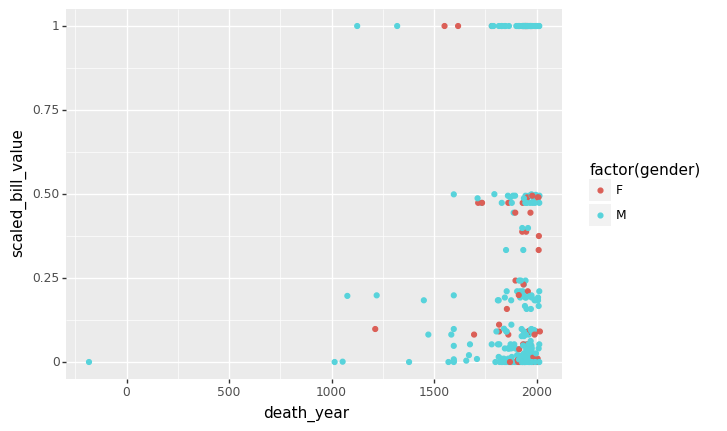

<ggplot: (328349123)>

In [29]:
(ggplot(to_plot) +
    geom_point(aes(x = "death_year", y = "scaled_bill_value", color = "factor(gender)"))
)

Now let's add labels to each point. To do this, we need to add another
geometry:

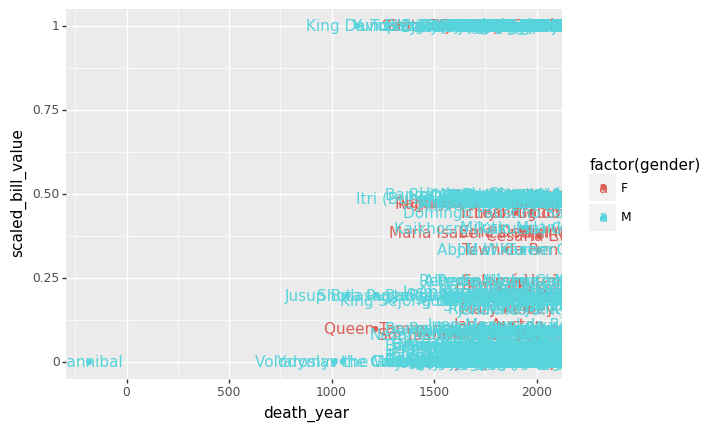

<ggplot: (328382918)>

In [30]:
(ggplot(to_plot,
    aes(x = "death_year", y = "scaled_bill_value", color = "factor(gender)",
        label = "name")) +
    geom_point() + 
    geom_text()
)

Where you put the aesthetics matters:

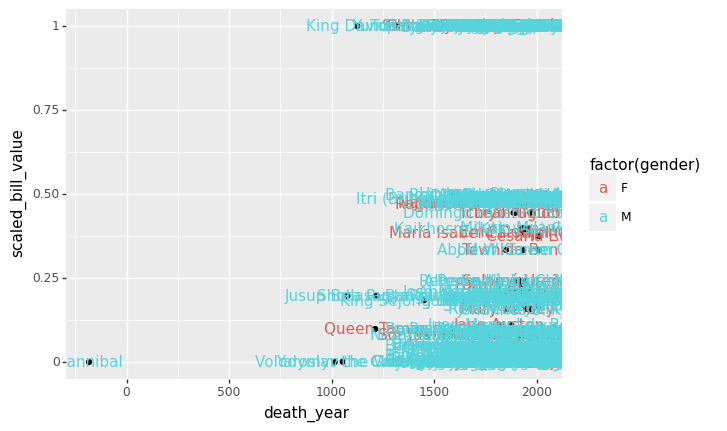

<ggplot: (328326883)>

In [31]:
(ggplot(to_plot,
    aes(x = "death_year", y = "scaled_bill_value", label = "name")) + 
    geom_point() + 
    geom_text(aes(color = "factor(gender)"))
)

**Constant Aesthetics**

If you want to set an aesthetic to a constant value, rather than one that's
data dependent, do so in the geometry layer rather than the aesthetic layer.
For instance, suppose you want to use point shape rather than color to indicate
gender, and you want to make all of the points blue.

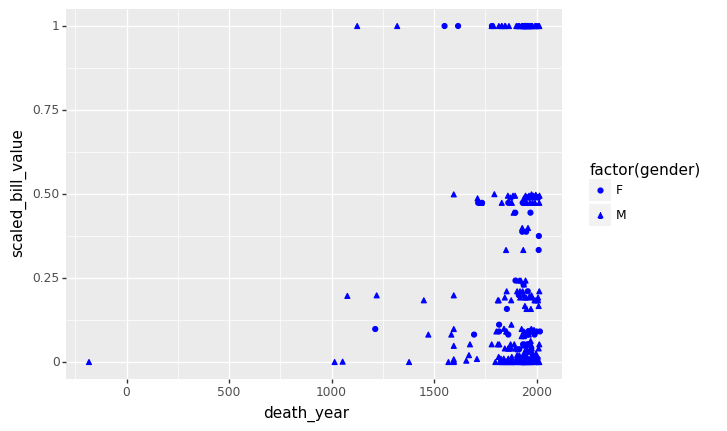

<ggplot: (328722955)>

In [32]:
(ggplot(to_plot,
    aes(x = "death_year", y = "scaled_bill_value", shape = "factor(gender)")) +
    geom_point(color = "blue")
)

If you set an aesthetic to a constant value inside of the aesthetic layer, the
results you get might not be what you expect:

In [33]:
(ggplot(to_plot,
    aes(x = "death_year", y = "scaled_bill_value", shape = "factor(gender)",
        color = "blue")) +
    geom_point()
)

PlotnineError: "Could not evaluate the 'color' mapping: 'blue' (original error: name 'blue' is not defined)"

### Layer 4: Scales

The scales layer controls the title, axis labels, and axis scales of the plot.
Most of the functions in the scales layer are prefixed with `scale_`, but not
all of them.

The `labs` function is especially important, because it's used to set the title
and axis labels. All graphs need a title and axis labels.

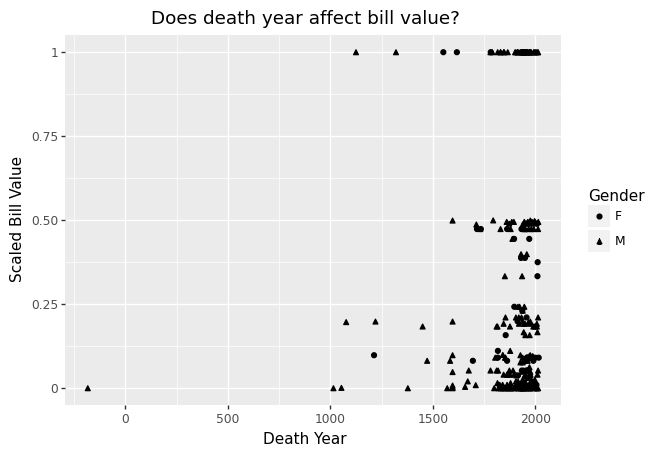

<ggplot: (328870681)>

In [34]:
(ggplot(to_plot,
    aes(x = "death_year", y = "scaled_bill_value", shape = "factor(gender)")) + 
    geom_point() +
    labs(x = "Death Year", y = "Scaled Bill Value",
         title = "Does death year affect bill value?", shape = "Gender")
)

### Saving Plots

If you assign a plot to a variable, you can use the `save` method or the
`ggsave` function to save that plot to a file:

```
plot = (
    ggplot(to_plot,
    aes(x = "death_year", y = "scaled_bill_value", shape = "factor(gender)")) +
    geom_point() +
    labs(x = "Death Year", y = "Scaled Bill Value", 
         title = "Does death year affect bill value?", shape = "Gender")
)

ggsave(plot, "myplot.pdf")
```

The file format is selected automatically based on the extension. Common
formats are PNG and PDF.


(example-bar-plot)=
### Example: Bar Plot

Now suppose you want to plot the number of banknotes with people from each
profession in the banknotes data set. A bar plot is an appropriate way to
represent this visually.

The geometry for a bar plot is `geom_bar`. Since bar plots are mainly used to
display frequencies, the `geom_bar` function automatically computes frequencies
when used in conjunction with the `factor()` syntax from above.

We can also use a fill color to further breakdown the bars by gender. Here's
the code to make the bar plot:

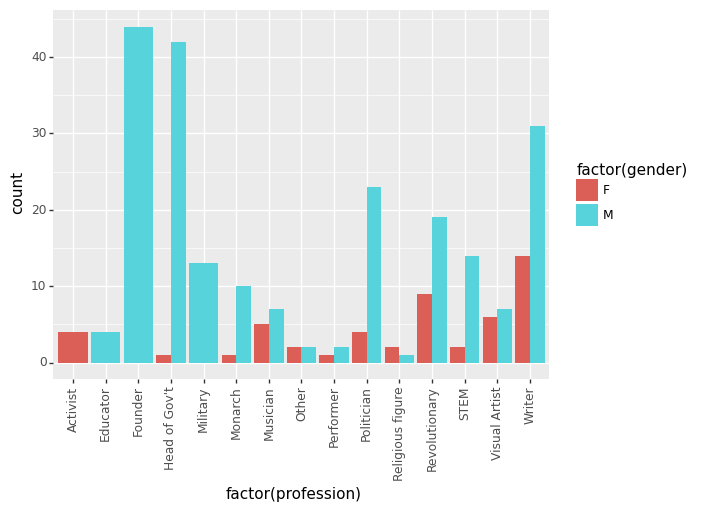

<ggplot: (328920542)>

In [35]:
(ggplot(to_plot,
    aes(x = "factor(profession)", fill = "factor(gender)")) +
    geom_bar(position = "dodge") + 
    theme(axis_text_x=element_text(rotation = 90))
)

The setting `position = "dodge"` instructs `geom_bar` to put the bars
side-by-side rather than stacking them. Adding `theme` allows you to change how
the axis labels and ticks are formatted.

In some cases, you may want to make a bar plot with frequencies you've already
computed. To prevent `geom_bar` from computing frequencies automatically, set
`stat = "identity"`.


(visualization-design)=
### Visualization Design

Designing high-quality visualizations goes beyond just mastering which Python
functions to call. You also need to think carefully about what kind of data you
have and what message you want to convey. This section provides a few
guidelines.

The first step in data visualization is choosing an appropriate kind of plot.
Here are some suggestions (not rules):

| Feature 1   | Feature 2   | Plot                          |
| :---------- | :---------- | :---------------------------- |
| categorical | categorical | bar, dot                      |
| categorical | categorical | bar, dot, mosaic              |
| numerical   |             | box, density, histogram       |
| numerical   | categorical | box, density, ridge           |
| numerical   | numerical   | line, scatter, smooth scatter |

If you want to add a:

* 3rd numerical feature, use it to change point/line size
* 3rd categorical feature, use it to change point/line style
* 4th categorical feature, use side-by-side plots

Once you've selected a plot, here are some rules you should almost always
follow:

* Always add a title and axis labels. These should be descriptive, not variable
  names!
* Specify units after the axis label if the axis has units. For instance,
  "Height (ft)"
* Don't forget that many people are colorblind! Also, plots are often printed
  in black and white. Use point and line styles to distinguish groups; color is
  optional
* Add a legend whenever you've used more than one point or line style
* Always write a few sentences explaining what the plot shows. Don't describe
  the plot, because the reader can just look at it. Instead, explain what they
  can learn from the plot and point out important details that may be
  overlooked
* For side-by-side plots, use the same axis scales for both plots so that
  comparing them is not deceptive

Visualization design is a deep topic, and whole books have been written about
it. One resource where you can learn more is DataLab's [Principle's of Data
Visualization Workshop Reader][rdr].

[rdr]: https://ucdavisdatalab.github.io/workshop_data_viz_principles/


Exercises
---------

### Exercise

1. Compute the number of banknotes that feature a person who died before 1990.
2. Of those people, how many were activists?

### Exercise

1. Compute the range of `first_appearance_year` for each country.
    + Hint: this would be a good place to try out a multi-function
      aggregation...
2. How many unique values are there among the first and last values of
  `first_appearance_year`?

### Exercise

1. Compute the set of banknotes who died in this century.
2. Use plotnine's `geom_segment` function to create a plot which shows the
  timespan between death year and first appearance as a horizontal segment for
  each banknote. Put the name of each person on the y-axis. Color code the
  segments by gender.
    + Hint: you can make the plot more visually appealing if you first sort the
      death year. You can use the `.sort_values` method to sort a DataFrame on
      a column, or set of columns. Be aware that the default parameter for one
      of the arguments is probably not what you're expecting.